# Hệ Thống Phát Hiện Gian Lận Thời Gian Thực (Real-Time Fraud Detection)

## Chủ đề: Quản trị rủi ro & Phát hiện gian lận

### Bối cảnh
Trước sự gia tăng của tội phạm công nghệ cao, các ví điện tử phải áp dụng phân tích Streaming để bảo vệ người dùng. Đặc biệt, từ năm 2025, việc áp dụng mạnh mẽ quy định của Ngân hàng Nhà nước về xác thực sinh trắc học và kiểm soát giao dịch bất thường là bắt buộc.

### Nhiệm vụ
- Xây dựng hệ thống phát hiện gian lận theo thời gian thực (Real-time detection)
- Tự động nhận diện hành vi bất thường: chuyển tiền liên tục vào tài khoản "Danh sách đen" (Blacklist)
- Kết hợp ML model + Rule-based detection

### Dataset
| Dataset | Mô tả | Mục đích |
|---------|--------|----------|
| `creditcard.csv` | Giao dịch thẻ tín dụng (PCA features) | Phân tích EDA, so sánh |
| `paysim.csv` | Mô phỏng giao dịch ví điện tử | Huấn luyện model + Streaming |

---

**Cách chạy để thấy biểu đồ:**

1. **Kernel → Restart Kernel and Run All** (chạy từ ô đầu theo thứ tự).

2. Chạy **một ô đầu tiên** (cấu hình + `%matplotlib inline` + import `pandas`, `matplotlib`, v.v.), sau đó mới chạy các ô load CSV / biểu đồ.

3. Biểu đồ hiển thị trong notebook nhờ `%matplotlib inline`. Ảnh PNG cũng được lưu vào `training/output/nb_*.png` (đưa vào báo cáo / slide).

4. Nếu báo không tìm thấy file CSV: trong VS Code dùng **File → Open Folder** mở thư mục `BigData` (chứa `data/`), rồi mở notebook.


---
## 1. Cấu hình, đường dẫn dữ liệu & thư viện


In [27]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
from pathlib import Path

# Tim thu muc project (co data/paysim.csv) du chay tu BigData hay training/
def resolve_data_dir():
    for base in [Path.cwd(), Path.cwd() / 'training', Path.cwd().parent]:
        base = base.resolve()
        if (base / 'data' / 'paysim.csv').exists():
            return base / 'data', base
    raise FileNotFoundError(
        'Khong tim thay data/paysim.csv. Hay: File -> Open Folder -> chon thu muc BigData, '
        'roi mo notebook tu training/, hoac chay Jupyter voi cwd = BigData.'
    )

DATA_DIR, PROJECT_ROOT = resolve_data_dir()
FIG_DIR = PROJECT_ROOT / 'training' / 'output'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(filename: str) -> Path:
    import matplotlib.pyplot as plt
    path = FIG_DIR / filename
    plt.savefig(path, dpi=150, bbox_inches='tight')
    # print(f'Da luu hinh: {path}')
    return path

print('DATA_DIR =', DATA_DIR)
print('FIG_DIR  =', FIG_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})

print('All libraries loaded successfully!')

DATA_DIR = D:\Class\Khoa\BigData\data
FIG_DIR  = D:\Class\Khoa\BigData\training\output
All libraries loaded successfully!


---
## 2. Exploratory Data Analysis (EDA)
### 2.1 Phân tích PaySim Dataset (Dataset chính - Mô phỏng ví điện tử)

In [28]:
print("Đang đọc paysim.csv...")
paysim_full = pd.read_csv(DATA_DIR / "paysim.csv")
print(f"Đã đọc xong: {paysim_full.shape[0]:,} dòng")

SAMPLE_NORMAL = 400_000
n_normal = len(paysim_full[paysim_full["isFraud"] == 0])
if len(paysim_full) > SAMPLE_NORMAL + paysim_full["isFraud"].sum():
    fraud_part = paysim_full[paysim_full["isFraud"] == 1]
    normal_part = paysim_full[paysim_full["isFraud"] == 0].sample(
        n=min(SAMPLE_NORMAL, n_normal),
        random_state=42,
    )
    paysim = pd.concat([fraud_part, normal_part], ignore_index=True)
    print(f"Dùng mẫu cho notebook: {len(paysim):,} dòng (tất cả fraud + {len(normal_part):,} normal)")
else:
    paysim = paysim_full.copy()

print(f"PaySim (làm việc) Shape: {paysim.shape}")
print(f"Columns: {list(paysim.columns)}")
print("Dataset mô phỏng ví điện tử (PaySim).")
print(f"Các loại giao dịch: {paysim['type'].unique()}")
paysim.head(10)

Đang đọc paysim.csv...
Đã đọc xong: 6,362,620 dòng
Dùng mẫu cho notebook: 408,213 dòng (tất cả fraud + 400,000 normal)
PaySim (làm việc) Shape: (408213, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Dataset mô phỏng ví điện tử (PaySim).
Các loại giao dịch: ['TRANSFER' 'CASH_OUT' 'PAYMENT' 'CASH_IN' 'DEBIT']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,0
1,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.00,1,0
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,0
4,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.00,1,0
5,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,0
6,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0
7,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,0
8,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,0
9,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.00,1,0


In [29]:
# Thống kê tổng quan
print('=== THỐNG KÊ TỔNG QUAN PAYSIM ===')
print(f'\nTổng số giao dịch: {len(paysim):,}')
print(f'Giao dịch gian lận: {paysim["isFraud"].sum():,}')
print(f'Tỷ lệ gian lận: {paysim["isFraud"].mean() * 100:.4f}%')
print(f'\nGiá trị giao dịch:')
print(f'  Min: ${paysim["amount"].min():,.2f}')
print(f'  Max: ${paysim["amount"].max():,.2f}')
print(f'  Mean: ${paysim["amount"].mean():,.2f}')
print(f'  Median: ${paysim["amount"].median():,.2f}')
print(f'\nMissing values:\n{paysim.isnull().sum()}')
print(f'\nData types:\n{paysim.dtypes}')

=== THỐNG KÊ TỔNG QUAN PAYSIM ===

Tổng số giao dịch: 408,213
Giao dịch gian lận: 8,213
Tỷ lệ gian lận: 2.0119%

Giá trị giao dịch:
  Min: $0.00
  Max: $69,886,731.30
  Mean: $204,916.21
  Median: $77,765.15

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


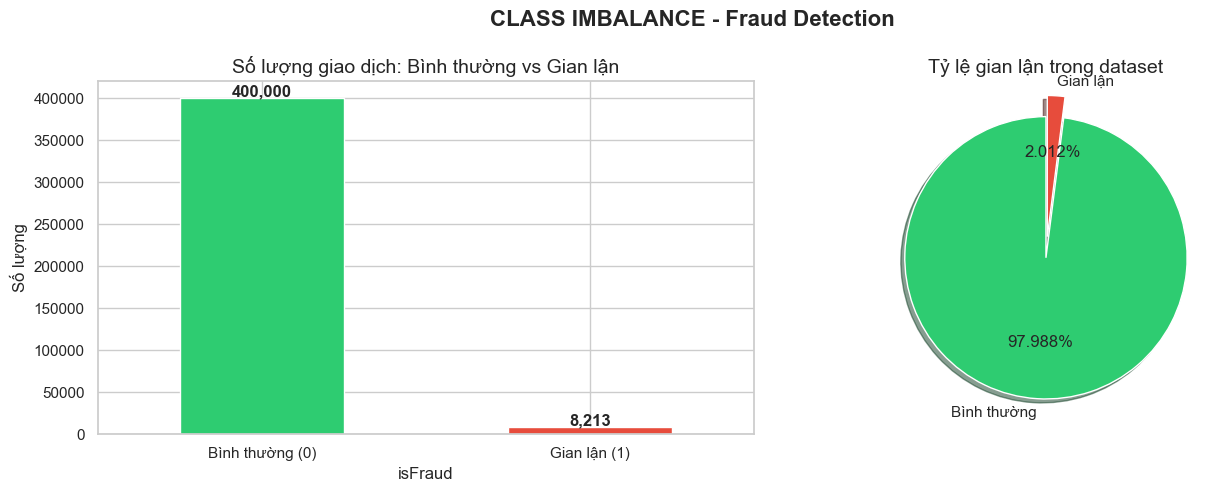

In [19]:
# Phân bố lớp (Class Imbalance) - Vấn đề cốt lõi trong Fraud Detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts = paysim['isFraud'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fraud_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Số lượng giao dịch: Bình thường vs Gian lận', fontsize=14)
axes[0].set_xticklabels(['Bình thường (0)', 'Gian lận (1)'], rotation=0)
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v + len(paysim)*0.005, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(fraud_counts, labels=['Bình thường', 'Gian lận'], 
            autopct='%1.3f%%', colors=colors, explode=(0, 0.15),
            shadow=True, startangle=90)
axes[1].set_title('Tỷ lệ gian lận trong dataset', fontsize=14)

plt.suptitle('CLASS IMBALANCE - Fraud Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
save_figure('nb_01_class_imbalance.png')
plt.show()


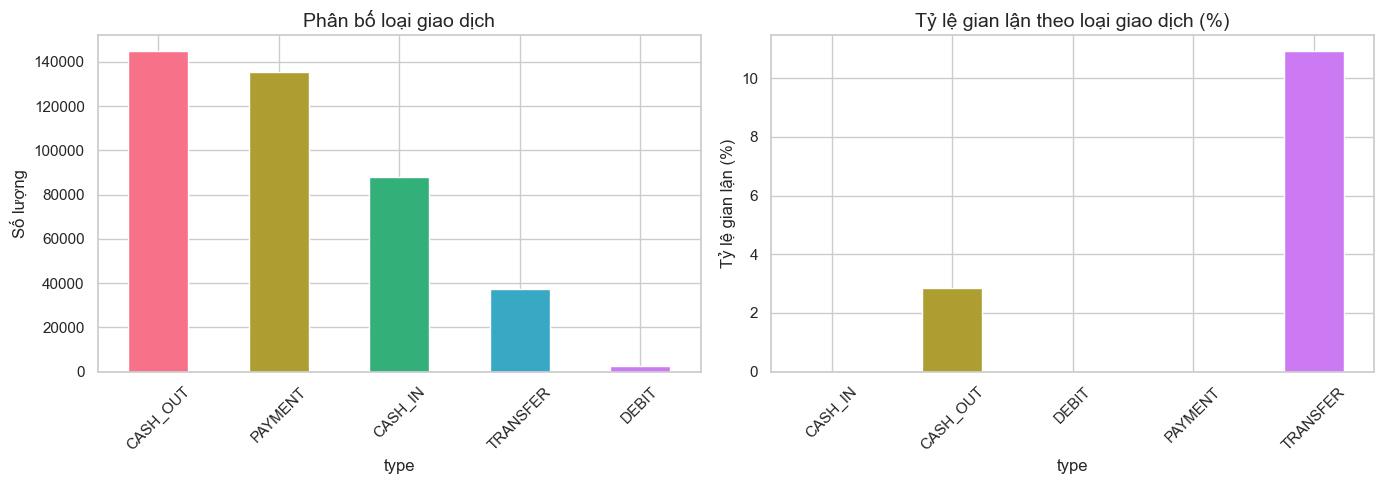


Thống kê chi tiết:
          Fraud Count   Total  Fraud Rate  Fraud Rate %
type                                                   
CASH_IN             0   87782    0.000000      0.000000
CASH_OUT         4116  144719    0.028441      2.844132
DEBIT               0    2634    0.000000      0.000000
PAYMENT             0  135559    0.000000      0.000000
TRANSFER         4097   37519    0.109198     10.919801

  Gian lận CHỈ xảy ra ở giao dịch TRANSFER và CASH_OUT


In [30]:
# Phân tích theo loại giao dịch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = paysim['type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('husl', len(type_counts)))
axes[0].set_title('Phân bố loại giao dịch', fontsize=14)
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=45)

fraud_by_type = paysim.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
fraud_by_type.columns = ['Fraud Count', 'Total', 'Fraud Rate']
fraud_by_type['Fraud Rate %'] = fraud_by_type['Fraud Rate'] * 100
(fraud_by_type['Fraud Rate %']).plot(kind='bar', ax=axes[1], 
    color=sns.color_palette('husl', len(fraud_by_type)))
axes[1].set_title('Tỷ lệ gian lận theo loại giao dịch (%)', fontsize=14)
axes[1].set_ylabel('Tỷ lệ gian lận (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_figure('nb_02_type_distribution.png')
plt.show()

print('\nThống kê chi tiết:')
print(fraud_by_type.to_string())
print('\n  Gian lận CHỈ xảy ra ở giao dịch TRANSFER và CASH_OUT')

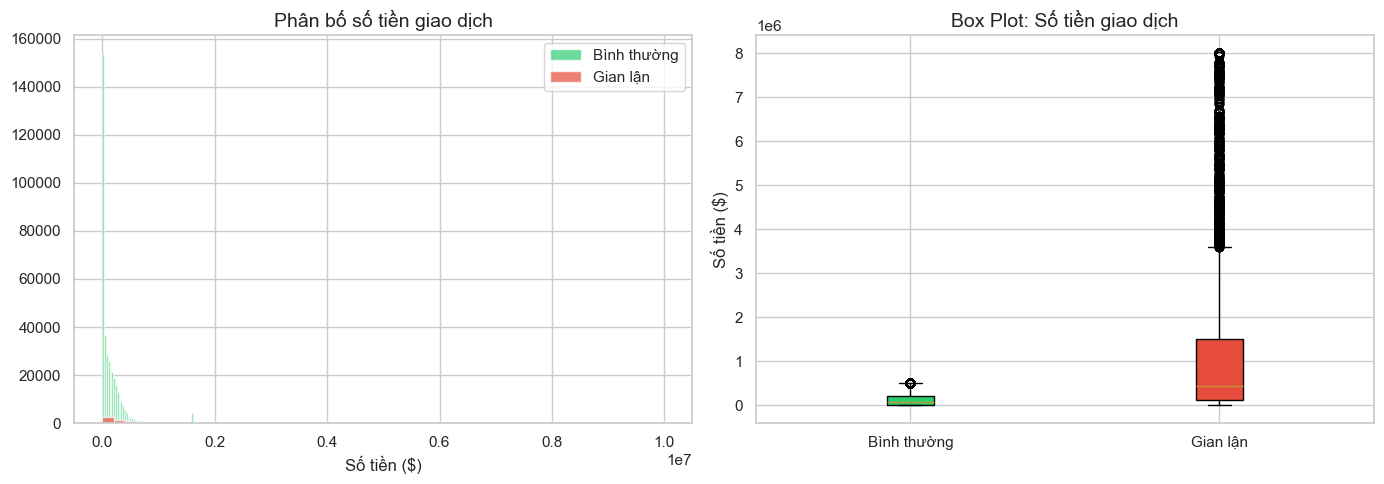

Số tiền trung bình giao dịch bình thường: $178,982.61
Số tiền trung bình giao dịch gian lận: $1,467,967.30

🔍 Giao dịch gian lận thường có số tiền LỚN HƠN ĐÁNG KỂ


In [23]:
# Phân tích số tiền giao dịch: Gian lận vs Bình thường
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_amt = paysim[paysim['isFraud'] == 0]['amount']
fraud_amt = paysim[paysim['isFraud'] == 1]['amount']

axes[0].hist(normal_amt.clip(upper=normal_amt.quantile(0.99)), bins=50, 
             alpha=0.7, label='Bình thường', color='#2ecc71')
axes[0].hist(fraud_amt.clip(upper=fraud_amt.quantile(0.99)), bins=50, 
             alpha=0.7, label='Gian lận', color='#e74c3c')
axes[0].set_title('Phân bố số tiền giao dịch', fontsize=14)
axes[0].set_xlabel('Số tiền ($)')
axes[0].legend()

data_box = [normal_amt.clip(upper=normal_amt.quantile(0.95)),
            fraud_amt.clip(upper=fraud_amt.quantile(0.95))]
bp = axes[1].boxplot(data_box, labels=['Bình thường', 'Gian lận'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Box Plot: Số tiền giao dịch', fontsize=14)
axes[1].set_ylabel('Số tiền ($)')

plt.tight_layout()
save_figure('nb_03_amount_distribution.png')
plt.show()

print(f'Số tiền trung bình giao dịch bình thường: ${normal_amt.mean():,.2f}')
print(f'Số tiền trung bình giao dịch gian lận: ${fraud_amt.mean():,.2f}')
print(f'\n🔍 Giao dịch gian lận thường có số tiền LỚN HƠN ĐÁNG KỂ')

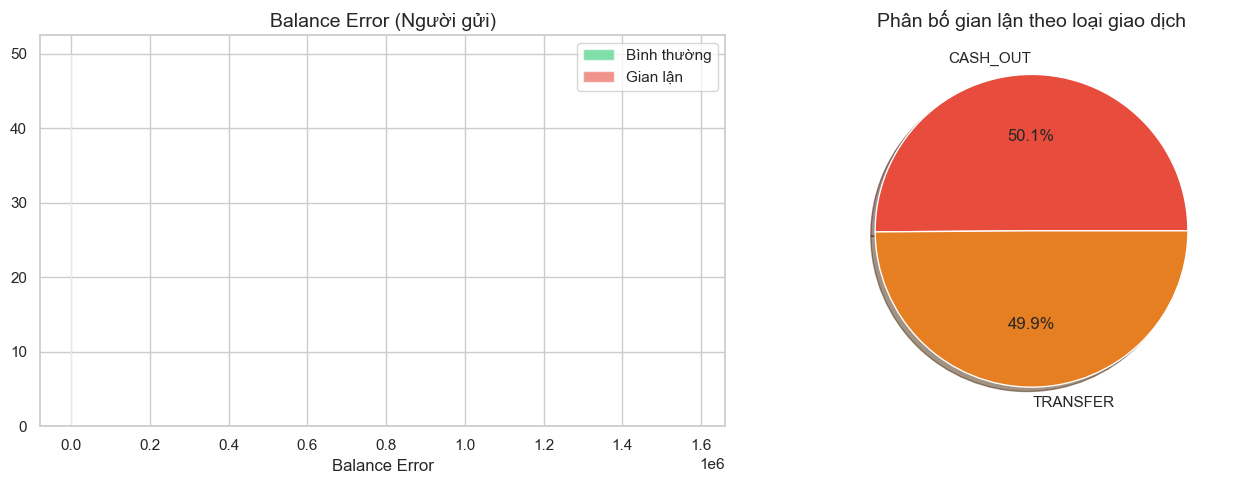

🔍 Balance Error ≠ 0 nghĩa là có bất thường trong sổ sách → dấu hiệu gian lận


In [24]:
# Phân tích pattern: Balance Error (dấu hiệu bất thường trong sổ sách)
paysim['balance_error_orig'] = paysim['newbalanceOrig'] + paysim['amount'] - paysim['oldbalanceOrg']
paysim['balance_change_orig'] = paysim['newbalanceOrig'] - paysim['oldbalanceOrg']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, val in [('Bình thường', '#2ecc71', 0), ('Gian lận', '#e74c3c', 1)]:
    subset = paysim[paysim['isFraud'] == val]['balance_error_orig']
    clipped = subset.clip(lower=subset.quantile(0.01), upper=subset.quantile(0.99))
    axes[0].hist(clipped, bins=50, alpha=0.6, label=label, color=color, density=True)
axes[0].set_title('Balance Error (Người gửi)', fontsize=14)
axes[0].set_xlabel('Balance Error')
axes[0].legend()

fraud_types = paysim[paysim['isFraud'] == 1]['type'].value_counts()
fraud_types.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                 colors=['#e74c3c', '#e67e22'], shadow=True)
axes[1].set_title('Phân bố gian lận theo loại giao dịch', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
save_figure('nb_04_balance_error.png')
plt.show()

print('🔍 Balance Error ≠ 0 nghĩa là có bất thường trong sổ sách → dấu hiệu gian lận')

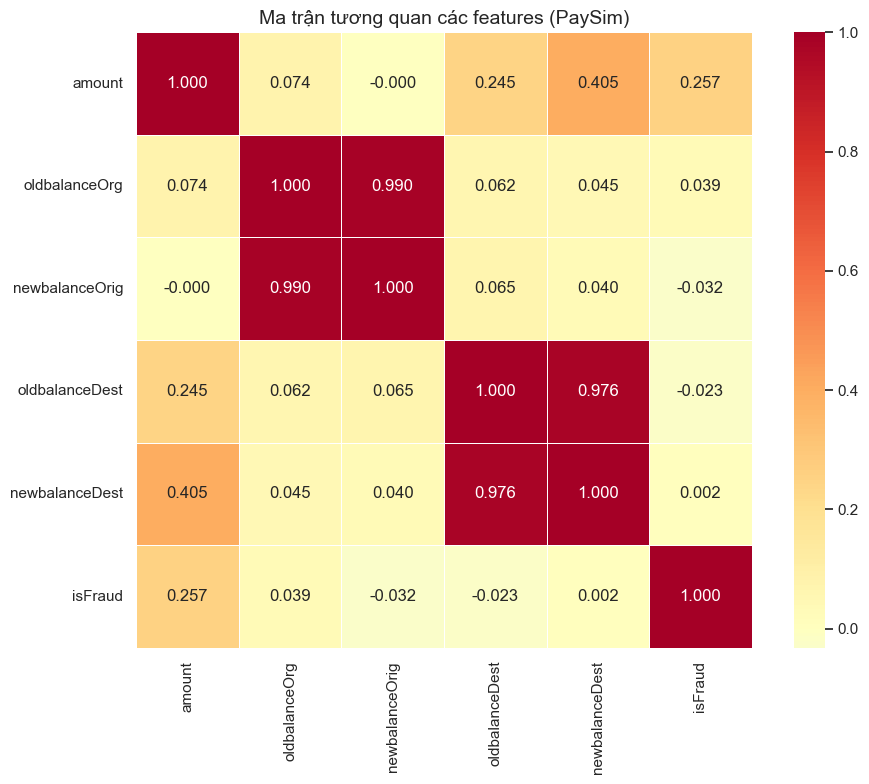

🔍 amount và oldbalanceOrg có tương quan thấp với isFraud
   → Cần Feature Engineering để tạo features mạnh hơn


In [25]:
# Correlation Heatmap
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = paysim[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('Ma trận tương quan các features (PaySim)', fontsize=14)
plt.tight_layout()
save_figure('nb_05_correlation.png')
plt.show()

print('🔍 amount và oldbalanceOrg có tương quan thấp với isFraud')
print('   → Cần Feature Engineering để tạo features mạnh hơn')

### 2.2 Phân tích Credit Card Dataset (Dataset phụ - So sánh)

In [26]:
# Load Credit Card dataset
cc = pd.read_csv(DATA_DIR / "creditcard.csv")

print(f'Credit Card Dataset Shape: {cc.shape}')
print(f'Columns: {list(cc.columns)}')
print(f'\nĐây là dataset giao dịch thẻ tín dụng với features đã qua PCA (ẩn danh)')
print(f'Tỷ lệ gian lận: {cc["Class"].mean() * 100:.4f}%')
print(f'Giao dịch gian lận: {cc["Class"].sum():,} / {len(cc):,}')
cc.head()

Credit Card Dataset Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Đây là dataset giao dịch thẻ tín dụng với features đã qua PCA (ẩn danh)
Tỷ lệ gian lận: 0.1727%
Giao dịch gian lận: 492 / 284,807


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# So sánh 2 dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit Card class distribution
cc_counts = cc['Class'].value_counts()
cc_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Credit Card: Normal vs Fraud', fontsize=14)
axes[0].set_xticklabels(['Normal', 'Fraud'], rotation=0)

# PCA components comparison
for feat, color in [('V1', '#3498db'), ('V14', '#e74c3c')]:
    axes[1].hist(cc[cc['Class']==0][feat], bins=50, alpha=0.4, label=f'{feat} Normal', density=True)
    axes[1].hist(cc[cc['Class']==1][feat], bins=50, alpha=0.4, label=f'{feat} Fraud', density=True)
axes[1].set_title('PCA Components: Normal vs Fraud', fontsize=14)
axes[1].legend()

plt.tight_layout()
save_figure('nb_06_creditcard_compare.png')
plt.show()

print('\n📊 So sánh 2 datasets:')
comparison = pd.DataFrame({
    'Dataset': ['PaySim', 'Credit Card'],
    'Records': [f'{len(paysim):,}', f'{len(cc):,}'],
    'Features': [len(paysim.columns), len(cc.columns)],
    'Fraud Count': [f'{paysim["isFraud"].sum():,}', f'{cc["Class"].sum():,}'],
    'Fraud Rate': [f'{paysim["isFraud"].mean()*100:.4f}%', f'{cc["Class"].mean()*100:.4f}%'],
    'Feature Type': ['Real (interpretable)', 'PCA (anonymized)'],
    'Dùng cho': ['Training + Streaming', 'EDA analysis'],
})
print(comparison.to_string(index=False))
print('\n⚠️ QUAN TRỌNG: 2 dataset có feature space KHÁC NHAU hoàn toàn!')
print('   → Train trên PaySim vì dữ liệu streaming đến từ PaySim')

---
## 3. Feature Engineering

Tạo các features phái sinh giúp model detect fraud hiệu quả hơn:
- **balance_change**: Thay đổi số dư
- **balance_error**: Sai lệch sổ sách (nên = 0 nếu giao dịch hợp lệ)
- **amount_ratio**: Tỷ lệ số tiền / số dư → phát hiện rút hết tiền
- **type encoding**: One-hot encode loại giao dịch

In [ ]:
TRANSACTION_TYPES = ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']

FEATURE_COLUMNS = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'balance_change_orig', 'balance_change_dest',
    'balance_error_orig', 'balance_error_dest',
    'amount_ratio',
    'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT',
    'type_PAYMENT', 'type_TRANSFER'
]

def engineer_features(df):
    """Feature Engineering pipeline - tạo features từ dữ liệu thô."""
    result = df.copy()
    
    # Derived features
    result['balance_change_orig'] = result['newbalanceOrig'] - result['oldbalanceOrg']
    result['balance_change_dest'] = result['newbalanceDest'] - result['oldbalanceDest']
    
    # Balance error: nên = 0 nếu giao dịch hợp lệ
    result['balance_error_orig'] = (
        result['newbalanceOrig'] + result['amount'] - result['oldbalanceOrg']
    )
    result['balance_error_dest'] = (
        result['oldbalanceDest'] + result['amount'] - result['newbalanceDest']
    )
    
    # Tỷ lệ tiền chuyển / số dư → phát hiện rút hết tiền
    result['amount_ratio'] = result['amount'] / (result['oldbalanceOrg'] + 1)
    
    # One-hot encoding loại giao dịch
    for t in TRANSACTION_TYPES:
        result[f'type_{t}'] = (result['type'] == t).astype(int)
    
    return result

# Apply feature engineering
df = engineer_features(paysim)

print(f'Features sau khi engineering: {len(FEATURE_COLUMNS)}')
print(f'\nDanh sách features:')
for i, col in enumerate(FEATURE_COLUMNS, 1):
    print(f'  {i:2d}. {col}')

# Hiển thị sample
print(f'\nSample data sau feature engineering:')
df[FEATURE_COLUMNS + ['isFraud']].head(10)

---
## 4. Blacklist Detection (Danh sách đen)

Xác định tài khoản "đen" dựa trên hành vi:
- Tài khoản **nhận tiền** từ nhiều giao dịch gian lận
- Tài khoản tham gia vào nhiều giao dịch bất thường liên tục

In [ ]:
# Phân tích Blacklist: Tài khoản nhận tiền gian lận nhiều nhất
fraud_txns = paysim[paysim['isFraud'] == 1]

# Top tài khoản đích nhận tiền gian lận
blacklist_dest = (
    fraud_txns.groupby('nameDest')
    .agg(
        fraud_count=('isFraud', 'sum'),
        total_fraud_amount=('amount', 'sum'),
        avg_fraud_amount=('amount', 'mean'),
    )
    .sort_values('fraud_count', ascending=False)
    .head(20)
)

print('🚨 TOP 20 TÀI KHOẢN TRONG DANH SÁCH ĐEN (nhận tiền gian lận nhiều nhất):')
print(blacklist_dest.to_string())

# Phân tích tài khoản nguồn gửi tiền gian lận
blacklist_orig = (
    fraud_txns.groupby('nameOrig')
    .agg(
        fraud_count=('isFraud', 'sum'),
        total_fraud_amount=('amount', 'sum'),
    )
    .sort_values('fraud_count', ascending=False)
    .head(10)
)

print(f'\n🔍 Tổng tài khoản đích tham gia gian lận: {fraud_txns["nameDest"].nunique():,}')
print(f'   Tổng tài khoản nguồn tham gia gian lận: {fraud_txns["nameOrig"].nunique():,}')

In [ ]:
# Visualization: Blacklist analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10 = blacklist_dest.head(10)
axes[0].barh(range(len(top10)), top10['total_fraud_amount'], color='#e74c3c')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels([n[:12] for n in top10.index], fontsize=9)
axes[0].set_title('Top 10 Blacklist - Tổng tiền gian lận nhận', fontsize=13)
axes[0].set_xlabel('Tổng số tiền ($)')

# Hành vi chuyển tiền liên tục
fraud_transfer = fraud_txns[fraud_txns['type'] == 'TRANSFER']
fraud_cashout = fraud_txns[fraud_txns['type'] == 'CASH_OUT']

axes[1].bar(['TRANSFER\n(Chuyển khoản)', 'CASH_OUT\n(Rút tiền)'], 
            [len(fraud_transfer), len(fraud_cashout)],
            color=['#e74c3c', '#e67e22'])
axes[1].set_title('Loại giao dịch gian lận', fontsize=13)
axes[1].set_ylabel('Số lượng')
for i, v in enumerate([len(fraud_transfer), len(fraud_cashout)]):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
save_figure('nb_blacklist.png')
plt.show()

# Lưu blacklist
blacklist_accounts = blacklist_dest.index.tolist()
print(f'\n✅ Đã xác định {len(blacklist_accounts)} tài khoản trong Danh sách đen')
print('   Sẽ được sử dụng trong Rule-based Detection của hệ thống streaming')

---
## 5. Model Training

1. **Split data**: 80% train, 20% test (stratified)
2. **Scale features**: StandardScaler
3. **Handle imbalance**: `class_weight='balanced'`
4. **Train 3 models**: LogisticRegression, RandomForest, GradientBoosting
5. **Đánh giá**: F1-Score (metric chính vì data imbalanced)

In [ ]:
# Chuẩn bị data
X = df[FEATURE_COLUMNS].values
y = df['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train):,} samples (Fraud: {y_train.sum():,})')
print(f'Test set:     {len(X_test):,} samples (Fraud: {y_test.sum():,})')
print(f'\nFraud ratio - Train: {y_train.mean()*100:.4f}% | Test: {y_test.mean()*100:.4f}%')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\n✅ Data đã được chuẩn bị xong!')

In [ ]:
# Train 3 models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        max_depth=15, min_samples_split=10,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=8,
        learning_rate=0.1, random_state=42
    ),
}

results = {}
for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    metrics = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
    }
    results[name] = metrics
    
    print(f'  Accuracy:  {metrics["accuracy"]:.4f}')
    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall:    {metrics["recall"]:.4f}')
    print(f'  F1-Score:  {metrics["f1"]:.4f}')
    print(f'  ROC-AUC:   {metrics["roc_auc"]:.4f}')
    print(f'  PR-AUC:    {metrics["pr_auc"]:.4f}')

print(f'\n✅ Tất cả models đã train xong!')

---
## 6. Model Evaluation & Comparison

In [ ]:
# So sánh performance các model
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
comparison_data = []
for name in results:
    for m in metric_names:
        comparison_data.append({'Model': name, 'Metric': m.upper(), 'Value': results[name][m]})

comp_df = pd.DataFrame(comparison_data)
pivot = comp_df.pivot(index='Metric', columns='Model', values='Value')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('So sánh hiệu suất các Model', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')

# ROC Curves
for name, color in zip(results, ['#3498db', '#2ecc71', '#e74c3c']):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['roc_auc']
    axes[1].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})', linewidth=2)
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
save_figure('nb_07_model_metrics_roc.png')
plt.show()

print('\n📊 Bảng so sánh chi tiết:')
print(pivot.round(4).to_string())

In [ ]:
# Confusion Matrix cho từng model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Bình thường', 'Gian lận'],
                yticklabels=['Bình thường', 'Gian lận'])
    axes[idx].set_title(f'{name}\n(F1={data["f1"]:.4f})', fontsize=12)
    axes[idx].set_xlabel('Dự đoán')
    axes[idx].set_ylabel('Thực tế')

plt.suptitle('Confusion Matrix - So sánh 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure('nb_08_confusion_matrices.png')
plt.show()

In [ ]:
# Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, color in zip(results, ['#3498db', '#2ecc71', '#e74c3c']):
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_prob'])
    pr_auc = results[name]['pr_auc']
    axes[0].plot(rec, prec, color=color, label=f'{name} (PR-AUC={pr_auc:.4f})', linewidth=2)
axes[0].set_title('Precision-Recall Curve', fontsize=14)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()

# Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
importance = pd.Series(rf_model.feature_importances_, index=FEATURE_COLUMNS)
importance.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Feature Importance (Random Forest)', fontsize=14)
axes[1].set_xlabel('Importance')

plt.tight_layout()
save_figure('nb_09_pr_feature_importance.png')
plt.show()

print('\n🔍 Top 5 features quan trọng nhất:')
for i, (feat, imp) in enumerate(importance.sort_values(ascending=False).head().items(), 1):
    print(f'  {i}. {feat}: {imp:.4f}')

---
## 7. Chọn Best Model & Lưu

In [ ]:
# Chọn model tốt nhất dựa trên F1-Score
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
best_metrics = {k: v for k, v in results[best_name].items() 
                if k not in ('model', 'y_pred', 'y_prob')}

print(f'🏆 BEST MODEL: {best_name}')
print(f'\n   F1-Score:  {best_metrics["f1"]:.4f}')
print(f'   Precision: {best_metrics["precision"]:.4f}')
print(f'   Recall:    {best_metrics["recall"]:.4f}')
print(f'   ROC-AUC:   {best_metrics["roc_auc"]:.4f}')

# Classification Report
print(f'\nClassification Report ({best_name}):')
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['Bình thường', 'Gian lận']))

In [ ]:
# Lưu model và config
from pathlib import Path

MODEL_DIR = PROJECT_ROOT / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save model + scaler
model_path = MODEL_DIR / 'fraud_model.pkl'
joblib.dump({
    'model': best_model,
    'scaler': scaler,
    'model_name': best_name,
    'metrics': best_metrics,
}, model_path)
print(f'✅ Model saved to {model_path}')

# Save feature config
config = {
    'feature_columns': FEATURE_COLUMNS,
    'transaction_types': TRANSACTION_TYPES,
    'model_name': best_name,
    'metrics': best_metrics,
    'blacklist_accounts': blacklist_accounts[:50],
    'thresholds': {
        'fraud_probability': 0.5,
        'high_amount': 200000,
        'balance_ratio_alert': 0.8,
    }
}
config_path = MODEL_DIR / 'feature_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'✅ Config saved to {config_path}')

print(f'\n🎉 Training pipeline hoàn tất!')
print(f'   Model sẵn sàng cho hệ thống streaming real-time')

---
## 8. Kiến trúc hệ thống Real-Time

```
┌────────────────────────────────────────────────────────────────┐
│                  FRAUD DETECTION SYSTEM                        │
├────────────────────────────────────────────────────────────────┤
│                                                                │
│  [PaySim CSV] ──► [Kafka Producer] ──► [Kafka Topic]          │
│                                            │                   │
│                                            ▼                   │
│                                   [Spark Streaming]            │
│                                    ┌──────┴──────┐             │
│                                    │             │              │
│                              [ML Model]   [Rule-Based]         │
│                              (trained)    (blacklist +         │
│                                           thresholds)          │
│                                    │             │              │
│                                    └──────┬──────┘             │
│                                           ▼                    │
│                                   [Kafka Output]               │
│                                           │                    │
│                                           ▼                    │
│                              [FastAPI Backend + WebSocket]      │
│                                    │             │              │
│                              [PostgreSQL]  [Next.js Dashboard]  │
│                                                                │
└────────────────────────────────────────────────────────────────┘
```

### Detection Strategy:
1. **ML Model**: RandomForest/GradientBoosting predict fraud probability
2. **Rule-Based**: High amount, balance ratio, blacklist, balance error
3. **Combined**: fraud = ML_prediction OR rule_based_flag

### Chạy hệ thống:
```bash
docker-compose up --build
```
- Dashboard: http://localhost:3000
- API Docs: http://localhost:8000/docs